In [2]:
import os
%load_ext autoreload
%autoreload 2

In [3]:
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/crytpo_DLOB-main/'

Mounted at /content/drive/
/content/drive/MyDrive/crytpo_DLOB-main


In [4]:
!pip install -r requirements_lujun.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
!pip install pytorch-tcn

[autoreload of jupyter_client.manager failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 410, in superreload
    update_generic(old_obj, new_obj)
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 347, in update_generic
    update(a, b)
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 302, in update_class
    if update_generic(old_obj, new_obj): continue
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 347, in update_generic
    update(a, b)
  File "/usr/local/lib/python3.11/dist-packages/IPython/extensions/autoreload.py", line 266, in update_function
    setattr(old, name, getattr(new, name))
ValueError: _laun

In [6]:
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset, LOBLazySequenceDataset
from training.trainer import Trainer, Config
from utils.utils import print_model_info

In [7]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
!pip install torch_xla #cloud-tpu-client==0.10 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.13-cp310-cp310-linux_x86_64.whl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 MB 15.4 MB/s eta 0:00:00


In [9]:
#import torch_xla
#import torch_xla.core.xla_model as xm

# Set the device to use TPU
#device = xm.xla_device()
#print(f"Using device: {device}")

In [10]:
print(os.getcwd())

/content/drive/MyDrive/crytpo_DLOB-main


# Horizon=100

In [79]:
with open("configs/tcn_1024_7_100.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [80]:
print(config.model.in_features)

7


In [81]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000108
Shape after label creation and NaN drop: (4817723, 8)
Label distribution:
label
1    0.450598
2    0.277158
0    0.272244
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

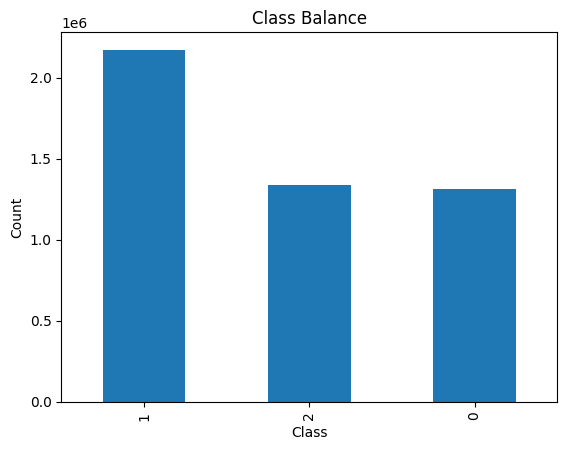

In [82]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [83]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372406, Val=722658, Test=722659


2826

In [84]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
100,70207.351562,69437.117188,0.1147,0.008940,69822.234375,-770.234375,0.855383,2
101,70207.351562,69440.851562,0.1147,0.000003,69824.101562,-766.500000,0.999946,2
102,70207.351562,69448.898438,0.1147,0.003000,69828.125000,-758.453125,0.949023,2
103,70207.351562,69443.328125,0.1147,0.003000,69825.343750,-764.023438,0.949023,2
104,70207.351562,69445.921875,0.1147,0.000003,69826.640625,-761.429688,0.999956,2


In [16]:
#if config.precision == 'float16' or None:
#    precision = np.float16
#elif config.precision == 'float32':
#    precision = np.float32
#elif config.precision == 'float64':
#    precision = np.float64
#
#print(f"Precision is: {precision}")

In [85]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [86]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
100,-1.13511,-1.249706,-0.105997,-0.064608,-1.197122,-0.879738,1.091485,2
101,-1.13511,-1.248787,-0.105997,-0.067792,-1.196655,-0.874096,1.279588,2
102,-1.13511,-1.246806,-0.105997,-0.066724,-1.195649,-0.861939,1.213328,2
103,-1.13511,-1.248177,-0.105997,-0.066724,-1.196345,-0.870354,1.213328,2
104,-1.13511,-1.247539,-0.105997,-0.067792,-1.196020,-0.866436,1.279601,2


In [87]:
config.sequence_length = 100

In [88]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm['label'].values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm['label'].values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True
if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=10,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=10,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=10,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [89]:
config.model.in_features = config.num_levels_features * 4 + 3

In [25]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337231, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [26]:
print(trainer.device)

cuda


In [ ]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 330
trainer.device cuda
Epoch[Batch]: [1][0/330]	Avg_Loss 1.296 (1.296)	 Time 1.133 (1.133)	
Epoch[Batch]: [1][33/330]	Avg_Loss 1.100 (1.154)	 Time 1.115 (1.103)	
Epoch[Batch]: [1][66/330]	Avg_Loss 1.069 (1.122)	 Time 1.097 (1.103)	
Epoch[Batch]: [1][99/330]	Avg_Loss 1.069 (1.106)	 Time 1.092 (1.102)	
Epoch[Batch]: [1][132/330]	Avg_Loss 1.063 (1.097)	 Time 1.109 (1.104)	
Epoch[Batch]: [1][165/330]	Avg_Loss 1.072 (1.092)	 Time 1.132 (1.104)	
Epoch[Batch]: [1][198/330]	Avg_Loss 1.069 (1.087)	 Time 1.100 (1.103)	
Epoch[Batch]: [1][231/330]	Avg_Loss 1.060 (1.083)	 Time 1.083 (1.103)	
Epoch[Batch]: [1][264/330]	Avg_Loss 1.056 (1.080)	 Time 1.095 (1.102)	
Epoch[Batch]: [1][297/330]	Avg_Loss 1.055 (1.077)	 Time 1.082 (1.102)	
Epoch 1/20 — Train loss: 1.0743 — Train F₁: 0.3530


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:257: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.8984 — Val F₁: 0.3458
Epoch finished in 450.34213386400006 seconds
  ↳ New best model (val_loss=0.8984), checkpoint saved.
Epoch[Batch]: [2][0/330]	Avg_Loss 1.045 (1.074)	 Time 1.098 (1.099)	
Epoch[Batch]: [2][33/330]	Avg_Loss 1.048 (1.072)	 Time 1.099 (1.098)	
Epoch[Batch]: [2][66/330]	Avg_Loss 1.045 (1.070)	 Time 1.093 (1.098)	
Epoch[Batch]: [2][99/330]	Avg_Loss 1.067 (1.068)	 Time 1.089 (1.098)	
Epoch[Batch]: [2][132/330]	Avg_Loss 1.009 (1.066)	 Time 1.109 (1.098)	
Epoch[Batch]: [2][165/330]	Avg_Loss 1.011 (1.064)	 Time 1.110 (1.098)	
Epoch[Batch]: [2][198/330]	Avg_Loss 1.051 (1.063)	 Time 1.105 (1.098)	
Epoch[Batch]: [2][231/330]	Avg_Loss 1.030 (1.061)	 Time 1.090 (1.098)	
Epoch[Batch]: [2][264/330]	Avg_Loss 1.035 (1.059)	 Time 1.105 (1.098)	
Epoch[Batch]: [2][297/330]	Avg_Loss 1.045 (1.058)	 Time 1.088 (1.098)	
Epoch 2/20 — Train loss: 1.0569 — Train F₁: 0.3995
  ↳ Val loss: 0.9168 — Val F₁: 0.3940
Epoch finished in 448.320928374 seconds
Epoch[Batch]: [3][0/330]	Av

In [ ]:
trainer.test()

In [76]:
model_path = os.getcwd()+"/results/tcn_1024_1_100_best_model.pt"

In [98]:
modelload = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337231, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [100]:
modelload.model.load_state_dict(torch.load(model_path, map_location=device))
#model = torch.load(model_path, map_location=device)

<All keys matched successfully>

In [102]:
modelload.test()

  ↳ Val loss: 1.0644 — Val F₁: 0.3534


(1.064447032550038, array(0.35344666, dtype=float32))

# Horizon=50

In [103]:
with open("configs/tcn_1024_7_50.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [104]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000072
Shape after label creation and NaN drop: (4817823, 8)
Label distribution:
label
1    0.470322
2    0.266240
0    0.263438
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

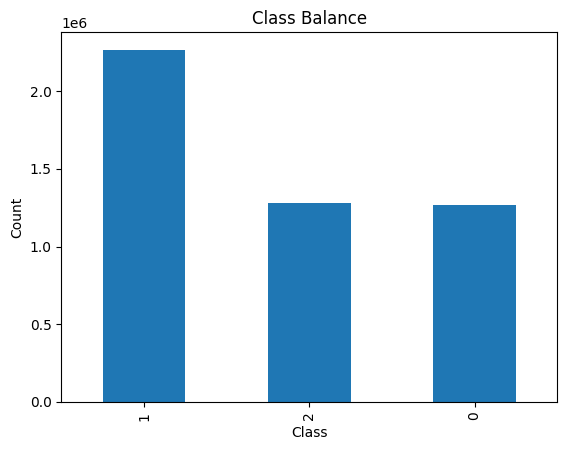

In [105]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [106]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372476, Val=722673, Test=722674


2837

In [107]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
50,70207.351562,69314.703125,0.1147,0.000004,69761.03125,-892.648438,0.999937,0
51,70207.351562,69329.468750,0.1147,0.000014,69768.40625,-877.882812,0.999758,0
52,70207.351562,69347.023438,0.1147,0.000277,69777.18750,-860.328125,0.995180,0
53,70207.351562,69346.703125,0.1147,0.028841,69777.03125,-860.648438,0.598154,1
54,70207.351562,69347.078125,0.1147,0.477119,69777.21875,-860.273438,-0.612382,1


In [108]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [109]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
50,-1.135079,-1.279794,-0.105996,-0.067791,-1.212394,-1.064676,1.279569,0
51,-1.135079,-1.276161,-0.105996,-0.067788,-1.210549,-1.042367,1.279335,0
52,-1.135079,-1.271841,-0.105996,-0.067694,-1.208354,-1.015845,1.273379,0
53,-1.135079,-1.271920,-0.105996,-0.057519,-1.208393,-1.016329,0.756777,1
54,-1.135079,-1.271827,-0.105996,0.102173,-1.208346,-1.015762,-0.818349,1


In [110]:
config.sequence_length = 100

In [111]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm['label'].values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm['label'].values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True
if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=10,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=10,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=10,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [112]:
config.model.in_features = config.num_levels_features * 4 + 3

In [24]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337238, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None


In [25]:
print(trainer.device)

cuda


In [26]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 330
trainer.device cuda


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:305: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch[Batch]: [1][0/330]	Avg_Loss 1.327 (1.327)	 Time 1.314 (1.314)	
Epoch[Batch]: [1][33/330]	Avg_Loss 1.085 (1.144)	 Time 1.153 (1.132)	
Epoch[Batch]: [1][66/330]	Avg_Loss 1.080 (1.110)	 Time 1.128 (1.127)	
Epoch[Batch]: [1][99/330]	Avg_Loss 1.061 (1.095)	 Time 1.108 (1.124)	
Epoch[Batch]: [1][132/330]	Avg_Loss 1.069 (1.087)	 Time 1.118 (1.124)	
Epoch[Batch]: [1][165/330]	Avg_Loss 1.057 (1.081)	 Time 1.126 (1.125)	
Epoch[Batch]: [1][198/330]	Avg_Loss 1.049 (1.076)	 Time 1.119 (1.124)	
Epoch[Batch]: [1][231/330]	Avg_Loss 1.037 (1.072)	 Time 1.132 (1.125)	
Epoch[Batch]: [1][264/330]	Avg_Loss 1.037 (1.069)	 Time 1.131 (1.125)	
Epoch[Batch]: [1][297/330]	Avg_Loss 1.015 (1.065)	 Time 1.114 (1.124)	
Epoch 1/20 — Train loss: 1.0622 — Train F₁: 0.3463


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:257: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.9132 — Val F₁: 0.3882
Epoch finished in 455.3153830209999 seconds
  ↳ New best model (val_loss=0.9132), checkpoint saved.
Epoch[Batch]: [2][0/330]	Avg_Loss 1.015 (1.062)	 Time 1.127 (1.122)	
Epoch[Batch]: [2][33/330]	Avg_Loss 1.025 (1.059)	 Time 1.120 (1.122)	
Epoch[Batch]: [2][66/330]	Avg_Loss 1.034 (1.057)	 Time 1.110 (1.122)	
Epoch[Batch]: [2][99/330]	Avg_Loss 1.007 (1.054)	 Time 1.158 (1.123)	
Epoch[Batch]: [2][132/330]	Avg_Loss 1.029 (1.052)	 Time 1.148 (1.125)	
Epoch[Batch]: [2][165/330]	Avg_Loss 1.024 (1.050)	 Time 1.126 (1.125)	
Epoch[Batch]: [2][198/330]	Avg_Loss 1.023 (1.049)	 Time 1.134 (1.126)	
Epoch[Batch]: [2][231/330]	Avg_Loss 1.018 (1.047)	 Time 1.194 (1.127)	
Epoch[Batch]: [2][264/330]	Avg_Loss 1.024 (1.046)	 Time 1.130 (1.127)	
Epoch[Batch]: [2][297/330]	Avg_Loss 1.024 (1.044)	 Time 1.138 (1.128)	
Epoch 2/20 — Train loss: 1.0431 — Train F₁: 0.4013
  ↳ Val loss: 0.9485 — Val F₁: 0.4066
Epoch finished in 460.81814258099985 seconds
Epoch[Batch]: [3][0/330

In [31]:
trainer.test()

[]

In [117]:
model_path = os.getcwd()+"/results/tcn_1024_1_50_best_model.pt"

In [118]:
modelload = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337238, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [119]:
modelload.model.load_state_dict(torch.load(model_path, map_location=device))
#model = torch.load(model_path, map_location=device)

<All keys matched successfully>

In [120]:
modelload.test()

  ↳ Val loss: 1.0485 — Val F₁: 0.3603


(1.0484936485823997, array(0.36030075, dtype=float32))

# Horizon=20

In [34]:
with open("configs/tcn_1024_7_20.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [35]:
print(config.model.in_features)

7


In [36]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000041
Shape after label creation and NaN drop: (4817883, 8)
Label distribution:
label
1    0.509792
2    0.245260
0    0.244949
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

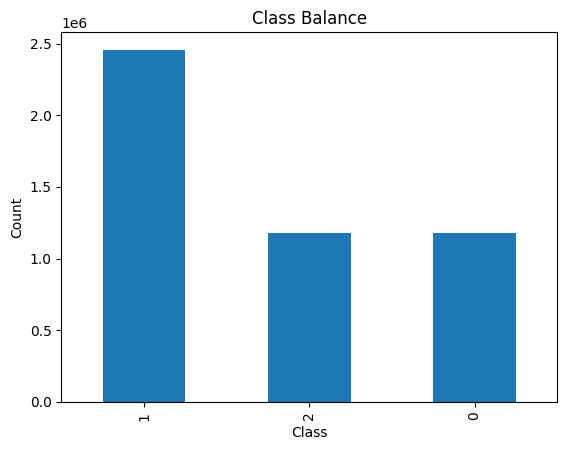

In [37]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [38]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372518, Val=722682, Test=722683


2957

In [39]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
20,70207.351562,69405.937500,0.1147,0.057632,69806.640625,-801.414062,0.331152,2
21,70207.351562,69415.000000,0.1147,0.040740,69811.171875,-792.351562,0.475806,1
22,70207.351562,69420.000000,0.1147,0.002484,69813.671875,-787.351562,0.957601,1
23,70207.351562,69437.078125,0.1147,0.057606,69822.218750,-770.273438,0.331352,0
24,70207.351562,69439.156250,0.1147,0.028802,69823.250000,-768.195312,0.598582,0


In [40]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [41]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
20,-1.13506,-1.257322,-0.105995,-0.047262,-1.200968,-0.926829,0.409356,2
21,-1.13506,-1.255092,-0.105995,-0.053279,-1.199835,-0.913137,0.597577,1
22,-1.13506,-1.253861,-0.105995,-0.066907,-1.199210,-0.905583,1.224481,1
23,-1.13506,-1.249658,-0.105995,-0.047271,-1.197073,-0.879780,0.409616,0
24,-1.13506,-1.249147,-0.105995,-0.057532,-1.196815,-0.876640,0.757331,0


In [42]:
config.sequence_length = 100

In [43]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm['label'].values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm['label'].values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True
if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=10,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=10,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=10,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [44]:
config.model.in_features = config.num_levels_features * 4 + 3

In [45]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337242, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [46]:
print(trainer.device)

cuda


In [47]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 330
trainer.device cuda


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:305: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch[Batch]: [1][0/330]	Avg_Loss 1.246 (1.246)	 Time 1.167 (1.167)	
Epoch[Batch]: [1][33/330]	Avg_Loss 1.067 (1.129)	 Time 1.117 (1.131)	
Epoch[Batch]: [1][66/330]	Avg_Loss 1.058 (1.093)	 Time 1.116 (1.126)	
Epoch[Batch]: [1][99/330]	Avg_Loss 1.028 (1.077)	 Time 1.128 (1.127)	
Epoch[Batch]: [1][132/330]	Avg_Loss 1.062 (1.067)	 Time 1.120 (1.128)	
Epoch[Batch]: [1][165/330]	Avg_Loss 1.025 (1.059)	 Time 1.134 (1.128)	
Epoch[Batch]: [1][198/330]	Avg_Loss 1.022 (1.053)	 Time 1.113 (1.127)	
Epoch[Batch]: [1][231/330]	Avg_Loss 1.011 (1.048)	 Time 1.154 (1.127)	
Epoch[Batch]: [1][264/330]	Avg_Loss 1.002 (1.043)	 Time 1.126 (1.128)	
Epoch[Batch]: [1][297/330]	Avg_Loss 1.018 (1.039)	 Time 1.135 (1.130)	
Epoch 1/20 — Train loss: 1.0351 — Train F₁: 0.3424


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:257: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.7914 — Val F₁: 0.3254
Epoch finished in 459.25264497599983 seconds
  ↳ New best model (val_loss=0.7914), checkpoint saved.
Epoch[Batch]: [2][0/330]	Avg_Loss 0.990 (1.035)	 Time 1.124 (1.129)	
Epoch[Batch]: [2][33/330]	Avg_Loss 1.000 (1.032)	 Time 1.152 (1.129)	
Epoch[Batch]: [2][66/330]	Avg_Loss 0.984 (1.029)	 Time 1.133 (1.129)	
Epoch[Batch]: [2][99/330]	Avg_Loss 1.004 (1.026)	 Time 1.129 (1.130)	
Epoch[Batch]: [2][132/330]	Avg_Loss 0.977 (1.024)	 Time 1.131 (1.130)	
Epoch[Batch]: [2][165/330]	Avg_Loss 1.005 (1.022)	 Time 1.177 (1.131)	
Epoch[Batch]: [2][198/330]	Avg_Loss 0.995 (1.020)	 Time 1.131 (1.131)	
Epoch[Batch]: [2][231/330]	Avg_Loss 0.988 (1.018)	 Time 1.138 (1.131)	
Epoch[Batch]: [2][264/330]	Avg_Loss 0.983 (1.016)	 Time 1.151 (1.132)	
Epoch[Batch]: [2][297/330]	Avg_Loss 1.000 (1.015)	 Time 1.143 (1.132)	
Epoch 2/20 — Train loss: 1.0134 — Train F₁: 0.3985
  ↳ Val loss: 0.8192 — Val F₁: 0.3694
Epoch finished in 460.6271940400002 seconds
Epoch[Batch]: [3][0/330

In [51]:
trainer.test()

/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:257: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 1.0075 — Val F₁: 0.3885


(1.0075296409256236, array(0.3885104, dtype=float32))

[]

# Horizon=10

In [52]:
with open("configs/tcn_1024_7_10.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [53]:
print(config.model.in_features)

7


In [54]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000026
Shape after label creation and NaN drop: (4817903, 8)
Label distribution:
label
1    0.554784
2    0.222725
0    0.222491
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

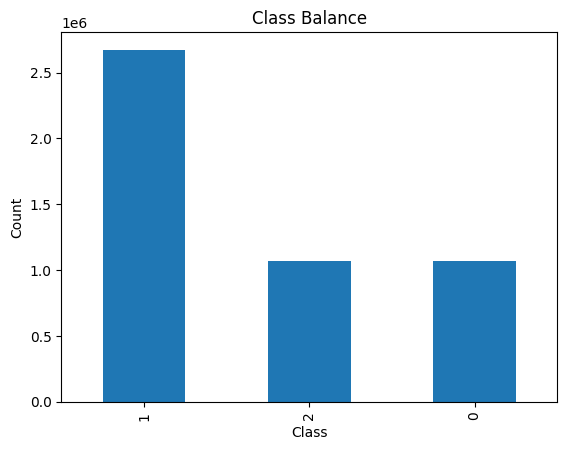

In [55]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [56]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372532, Val=722685, Test=722686


2942

In [57]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
10,70207.351562,69387.257812,0.1147,0.032416,69797.304688,-820.093750,0.559310,2
11,70207.351562,69380.929688,0.1147,0.028826,69794.140625,-826.421875,0.598313,2
12,70207.351562,69380.992188,0.1147,0.013600,69794.171875,-826.359375,0.787997,2
13,70207.351562,69387.273438,0.1147,0.009067,69797.312500,-820.078125,0.853482,2
14,70207.351562,69387.273438,0.1147,0.004919,69797.312500,-820.078125,0.917750,2


In [58]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [59]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
10,-1.135054,-1.261911,-0.105994,-0.056245,-1.203296,-0.955049,0.706228,2
11,-1.135054,-1.263469,-0.105994,-0.057524,-1.204087,-0.964610,0.756978,2
12,-1.135054,-1.263453,-0.105994,-0.062948,-1.204079,-0.964516,1.003791,2
13,-1.135054,-1.261908,-0.105994,-0.064562,-1.203294,-0.955026,1.088999,2
14,-1.135054,-1.261908,-0.105994,-0.066040,-1.203294,-0.955026,1.172624,2


In [60]:
config.sequence_length = 100

In [61]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm['label'].values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm['label'].values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True
if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=10,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=10,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=10,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [62]:
config.model.in_features = config.num_levels_features * 4 + 3

In [63]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 330
Number of validation batches: 71
Number of testing batches: 71
Input Size: torch.Size([1024, 7, 100])
device used in trainer: cuda
input.shape: (337244, 100, 7)
Model: TCN model

🧠 Total parameters: 6,147
🎯 Trainable parameters: 6,147


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [64]:
print(trainer.device)

cuda


In [65]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 330
trainer.device: cuda


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:305: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch[Batch]: [1][0/330]	Avg_Loss 1.285 (1.285)	 Time 1.133 (1.133)	
Epoch[Batch]: [1][33/330]	Avg_Loss 1.024 (1.110)	 Time 1.118 (1.129)	
Epoch[Batch]: [1][66/330]	Avg_Loss 0.994 (1.069)	 Time 1.143 (1.128)	
Epoch[Batch]: [1][99/330]	Avg_Loss 1.012 (1.050)	 Time 1.119 (1.137)	
Epoch[Batch]: [1][132/330]	Avg_Loss 0.973 (1.038)	 Time 1.128 (1.135)	
Epoch[Batch]: [1][165/330]	Avg_Loss 0.984 (1.028)	 Time 1.146 (1.132)	
Epoch[Batch]: [1][198/330]	Avg_Loss 1.005 (1.021)	 Time 1.121 (1.131)	
Epoch[Batch]: [1][231/330]	Avg_Loss 0.946 (1.015)	 Time 1.118 (1.130)	
Epoch[Batch]: [1][264/330]	Avg_Loss 0.955 (1.010)	 Time 1.117 (1.129)	
Epoch[Batch]: [1][297/330]	Avg_Loss 0.974 (1.005)	 Time 1.175 (1.131)	
Epoch 1/20 — Train loss: 1.0014 — Train F₁: 0.3308


/content/drive/MyDrive/crytpo_DLOB-main/training/trainer.py:257: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.7417 — Val F₁: 0.3152
Epoch finished in 458.54220953300137 seconds
  ↳ New best model (val_loss=0.7417), checkpoint saved.
Epoch[Batch]: [2][0/330]	Avg_Loss 0.942 (1.001)	 Time 1.127 (1.128)	
Epoch[Batch]: [2][33/330]	Avg_Loss 0.956 (0.998)	 Time 1.144 (1.128)	
Epoch[Batch]: [2][66/330]	Avg_Loss 0.954 (0.994)	 Time 1.147 (1.129)	
Epoch[Batch]: [2][99/330]	Avg_Loss 0.945 (0.991)	 Time 1.121 (1.129)	
Epoch[Batch]: [2][132/330]	Avg_Loss 0.975 (0.989)	 Time 1.124 (1.129)	
Epoch[Batch]: [2][165/330]	Avg_Loss 0.938 (0.986)	 Time 1.110 (1.129)	
Epoch[Batch]: [2][198/330]	Avg_Loss 0.943 (0.984)	 Time 1.125 (1.129)	
Epoch[Batch]: [2][231/330]	Avg_Loss 0.934 (0.981)	 Time 1.143 (1.129)	
Epoch[Batch]: [2][264/330]	Avg_Loss 0.934 (0.979)	 Time 1.143 (1.129)	
Epoch[Batch]: [2][297/330]	Avg_Loss 0.957 (0.977)	 Time 1.119 (1.129)	
Epoch 2/20 — Train loss: 0.9759 — Train F₁: 0.3908
  ↳ Val loss: 0.7501 — Val F₁: 0.3720
Epoch finished in 458.09346826399997 seconds
Epoch[Batch]: [3][0/33

In [66]:
trainer.test()

  ↳ Val loss: 0.9554 — Val F₁: 0.3649


(0.9553659763714832, array(0.36491042, dtype=float32))